### 時系列データの描画

In [1]:
# 数値演算、描画用ライブラリ読み込み
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# グラフをinline表示可能にする
%matplotlib inline
# 解像度を上げてinline表示する
%config InlineBackend.figure_format = 'retina'

# 日本語表示用ライブラリ（matplotlibで日本語を使用したい場合）
try:
    import japanize_matplotlib
except ModuleNotFoundError:
    # 初回だけインストールするので時間がかかる
    !pip install japanize-matplotlib
    import japanize_matplotlib

In [2]:
# datetime型を扱うためのライブラリを読み込む
import datetime

Pythonでは、日付と時間を扱うためのデータ型 `Datetime` が用意されており、これを用いて時系列データを
扱います。  

datetimeモジュールの4つのクラス：
1. datetime.date:  
日付を扱うためのクラスで、年、月、日を含む。

1. datetime.time:  
時刻を扱うためのクラスで、時、分、秒、マイクロ秒を含む。

1. datetime.datetime:  
日付と時刻の両方を扱うためのクラスで、dateとtimeクラスの組み合わせ。年、月、日、時、分、秒、マイクロ秒を含む。

1. datetime.timedelta:  
2つのdatetimeオブジェクト間の差を表すクラス。時間の長さや期間を計算するのに用いる。

In [3]:
# 現在日時の取得
print(datetime.date.today())
print(datetime.datetime.now())
print(datetime.datetime.today())

2025-11-22
2025-11-22 09:52:23.966433
2025-11-22 09:52:23.966523


In [4]:
print(datetime.datetime.now())
print(datetime.date.today())
print(datetime.date.today().weekday())
print(datetime.datetime.now().time())
print(datetime.datetime.now().date())

2025-11-22 09:52:23.977286
2025-11-22
5
09:52:23.978018
2025-11-22


In [5]:
# 型の確認
t0 = datetime.datetime.now()
print(type(t0))

<class 'datetime.datetime'>


In [6]:
# 表示形式を指定
print(datetime.datetime.now().strftime('%Y-%m-%d（%a） %H:%M:%S'))

2025-11-22（Sat） 09:52:23


#### 書式コード (document)
https://docs.python.org/ja/3/library/datetime.html#strftime-and-strptime-format-codes

主なもの  
%d: 0埋めした10進数で表記した月中の日にち  
%m: 0埋めした10進数で表記した月  
%y: 0埋めした10進数で表記した西暦の下2桁  
%Y: 0埋めした10進数で表記した西暦4桁  
%H: 0埋めした10進数で表記した時 （24時間表記）  
%I: 0埋めした10進数で表記した時 （12時間表記）  
%M: 0埋めした10進数で表記した分  
%S: 0埋めした10進数で表記した秒  
%f: 0埋めした10進数で表記したマイクロ秒（6桁）  
%A: ロケールの曜日名  
%a: ロケールの曜日名（短縮形）  
%B: ロケールの月名  
%b: ロケールの月名（短縮形）  
%j: 0埋めした10進数で表記した年中の日にち（正月が'001'）  
%U: 0埋めした10進数で表記した年中の週番号 （週の始まりは日曜日）  
%W: 0埋めした10進数で表記した年中の週番号 （週の始まりは月曜日）

In [7]:
print(datetime.datetime(2025,11,18,10,0,30))
print(datetime.date(2019,12,6))
print(datetime.time(10,0,30))

2025-11-18 10:00:30
2019-12-06
10:00:30


In [8]:
# システムで設定されているロケール（言語や国・地域ごとの設定）を使って国に依存する書式設定を設定・取得するためのライブラリ
import locale
locale.setlocale(locale.LC_ALL, 'ja_JP.UTF-8')
now = datetime.datetime.now()
print(now.strftime('%A'))
print(now.strftime('%a'))
print(datetime.datetime.now().strftime('%Y-%m-%d（%a） %H:%M:%S'))

土曜日
土
2025-11-22（土） 09:52:24


In [9]:
# システムで設定されているロケール（言語や国・地域ごとの設定）を使って国に依存する書式設定を設定・取得するためのライブラリ
import locale
locale.setlocale(locale.LC_ALL, 'en_US')
now = datetime.datetime.now()
print(now.strftime('%A'))
print(now.strftime('%a'))
print(datetime.datetime.now().strftime('%Y-%m-%d（%a） %H:%M:%S'))

Saturday
Sat
2025-11-22（Sat） 09:52:24


In [10]:
# 表示形式を指定
print(datetime.datetime.now().strftime('%Y-%m-%d（%a） %H:%M:%S'))

2025-11-22（Sat） 09:52:24


In [11]:
# 創生学部設置日
dt_founded = datetime.datetime(year=2017, month=4, day=1)
print(dt_founded)

2017-04-01 00:00:00


In [12]:
# 創生学部設置からの日数
td = datetime.datetime.today() - dt_founded
print(td)
td

3157 days, 9:52:24.141732


datetime.timedelta(days=3157, seconds=35544, microseconds=141732)

In [13]:
# 経過日数の取り出し
td.days

3157

In [14]:
# f文字列で文章に埋め込む
print(f'創生学部設置以来、今日は {td.days} 日目です。')
print(f'創生学部設置以来、今日は {td.days:,} 日目です。')

創生学部設置以来、今日は 3157 日目です。
創生学部設置以来、今日は 3,157 日目です。


In [15]:
td = datetime.timedelta(days=1)
td

datetime.timedelta(days=1)

In [16]:
# 日付の和・差
print(datetime.datetime.today() + td)
print(datetime.datetime.today() - td)

2025-11-23 09:52:24.198565
2025-11-21 09:52:24.199341


In [17]:
# 10週の和と差
td = datetime.timedelta(weeks=10)

# 日付の和・差
print(datetime.datetime.today() + td)
print(datetime.datetime.today() - td)

2026-01-31 09:52:24.208543
2025-09-13 09:52:24.209044


In [18]:
today = datetime.date.today()
days_togo = 1000
td = datetime.timedelta(days=days_togo)
print(f'本日から {days_togo:,} 日後の日付は、{today+td} です。')

本日から 1,000 日後の日付は、2028-08-18 です。


In [19]:
# 締切日までの日数計算
dt_duedate = datetime.date(year=2025, month=12, day=26)
print(dt_duedate)
td = datetime.timedelta(days=days_togo)
print(f'締切日[{dt_duedate}]まで、あと {(dt_duedate - today).days} 日です。')

2025-12-26
締切日[2025-12-26]まで、あと 34 日です。


In [20]:
# 条件抽出などに使えます
datetime.date(2025,11,1) < datetime.date(2025,11,10)

True

In [21]:
# excelファイルの読み込み
df_ts = pd.read_excel(r"d:\desktop\TimeSeriesResult_20251121212157730.xlsx")
df_ts.head()

,時点,地域コード,地域,総人口（総数）【人】,注記
0,27668,0,全国,111939643,総務省統計局「国勢調査」による。
1,27699,0,全国,112041000,NaN
2,27729,0,全国,112135000,NaN
3,27760,0,全国,112175000,NaN
4,27791,0,全国,112310000,NaN


In [22]:
# 情報取得：時点が int64（シリアル値）になっている
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   時点          602 non-null    int64 
 1   地域コード       602 non-null    int64 
 2   地域          602 non-null    object
 3   総人口（総数）【人】  602 non-null    int64 
 4   注記          15 non-null     object
dtypes: int64(3), object(2)
memory usage: 23.6+ KB


In [23]:
# 新たに「日付」列を作ってdatetime型の日付を格納
df_ts['日付'] = pd.to_timedelta(df_ts['時点'], unit='D') + pd.to_datetime("1899/12/30")
df_ts

,時点,地域コード,地域,総人口（総数）【人】,注記,日付
0,27668,0,全国,111939643,総務省統計局「国勢調査」による。,1975-10-01
1,27699,0,全国,112041000,NaN,1975-11-01
2,27729,0,全国,112135000,NaN,1975-12-01
3,27760,0,全国,112175000,NaN,1976-01-01
4,27791,0,全国,112310000,NaN,1976-02-01
...,...,...,...,...,...,...
597,45839,0,全国,123300000,速報,2025-07-01
598,45870,0,全国,123300000,速報,2025-08-01
599,45901,0,全国,123170000,速報,2025-09-01
600,45931,0,全国,123210000,速報,2025-10-01


In [24]:
# 再確認：「日付」列は datetime型となっている
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   時点          602 non-null    int64         
 1   地域コード       602 non-null    int64         
 2   地域          602 non-null    object        
 3   総人口（総数）【人】  602 non-null    int64         
 4   注記          15 non-null     object        
 5   日付          602 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 28.3+ KB


In [25]:
# インデックス設定
df_ts = df_ts.set_index('日付')
df_ts

,時点,地域コード,地域,総人口（総数）【人】,注記
日付,,,,,
1975-10-01,27668,0,全国,111939643,総務省統計局「国勢調査」による。
1975-11-01,27699,0,全国,112041000,NaN
1975-12-01,27729,0,全国,112135000,NaN
1976-01-01,27760,0,全国,112175000,NaN
1976-02-01,27791,0,全国,112310000,NaN
...,...,...,...,...,...
2025-07-01,45839,0,全国,123300000,速報
2025-08-01,45870,0,全国,123300000,速報
2025-09-01,45901,0,全国,123170000,速報


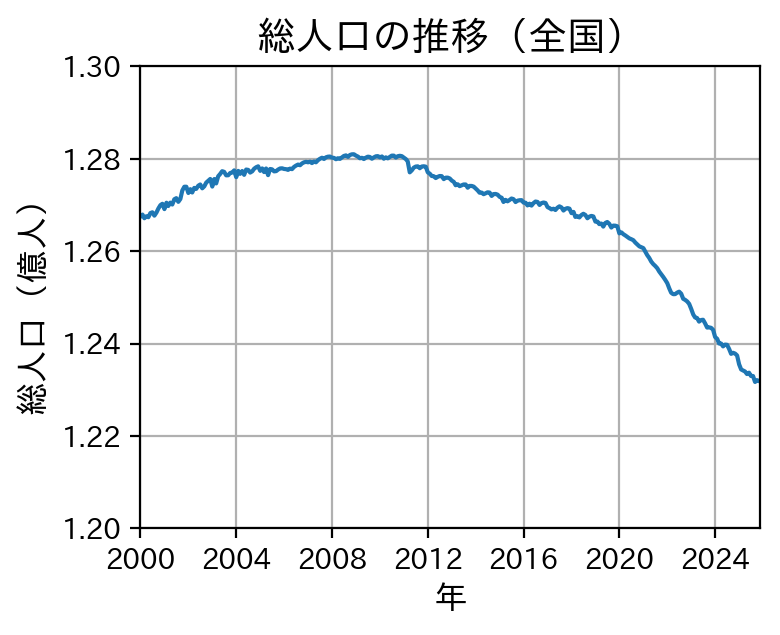

In [26]:
plt.figure(figsize=(4,3))
plt.plot(df_ts['総人口（総数）【人】']/1e8)

# 諸設定
plt.title("総人口の推移（全国）", fontsize=14)
plt.xlabel('年', fontsize=12)
plt.ylabel('総人口（億人）', fontsize=12)
plt.grid()

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2000, 1, 1), datetime.date.today())
plt.ylim(1.2, 1.3)
plt.show()

#### 米 ダウ工業株30種平均（週次）
Data Source　[Historical data: Dow Jones Industrial - U.S. (DJI)](https://stooq.com/q/d/?s=^dji&i=w&l=160)

In [27]:
# おまじない追加（ネット情報取得用ライブラリ） 
import urllib.request

# Excelファイルのネット上のアドレスを指定（熊野研サーバーからファイル取得）
url1 = 'https://create.niigata-u.ac.jp/public/lecture/dsa/dji_w.xlsx'
url2 = 'https://create.niigata-u.ac.jp/public/lecture/dsa/exchange.xlsx'

# 指定URLから Excelファイル の取得＆読み込み
urllib.request.urlretrieve(url1, 'dji_w.xlsx')
urllib.request.urlretrieve(url2, 'exchange.xlsx');

In [28]:
# excelファイルの読み込み
df_dj = pd.read_excel('dji_w.xlsx')
df_dj

,Date,Open,High,Low,Close,Volume
0,1900-01-07,49.34,49.34,48.24,48.31,0.000000e+00
1,1900-01-14,48.10,48.10,45.82,47.03,0.000000e+00
2,1900-01-21,46.51,47.29,46.51,47.29,0.000000e+00
3,1900-01-28,47.34,47.34,46.52,46.52,0.000000e+00
4,1900-02-04,46.68,49.15,46.68,49.15,0.000000e+00
...,...,...,...,...,...,...
6540,2025-09-28,46206.69,46714.27,45785.17,46247.29,2.276340e+09
6541,2025-10-05,46306.34,47049.64,46103.39,46758.28,2.092663e+09
6542,2025-10-12,46776.04,46868.49,45475.30,45479.60,1.902386e+09
6543,2025-10-19,45698.46,46693.34,45452.03,46190.61,1.708581e+09


In [29]:
# 情報取得　Dateのデータ型が datetime になっている
df_dj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6545 entries, 0 to 6544
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6545 non-null   datetime64[ns]
 1   Open    6545 non-null   float64       
 2   High    6545 non-null   float64       
 3   Low     6545 non-null   float64       
 4   Close   6545 non-null   float64       
 5   Volume  6545 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 306.9 KB


In [30]:
# Date列をインデックスに設定
df_dj = df_dj.set_index('Date')
df_dj

,Open,High,Low,Close,Volume
Date,,,,,
1900-01-07,49.34,49.34,48.24,48.31,0.000000e+00
1900-01-14,48.10,48.10,45.82,47.03,0.000000e+00
1900-01-21,46.51,47.29,46.51,47.29,0.000000e+00
1900-01-28,47.34,47.34,46.52,46.52,0.000000e+00
1900-02-04,46.68,49.15,46.68,49.15,0.000000e+00
...,...,...,...,...,...
2025-09-28,46206.69,46714.27,45785.17,46247.29,2.276340e+09
2025-10-05,46306.34,47049.64,46103.39,46758.28,2.092663e+09
2025-10-12,46776.04,46868.49,45475.30,45479.60,1.902386e+09


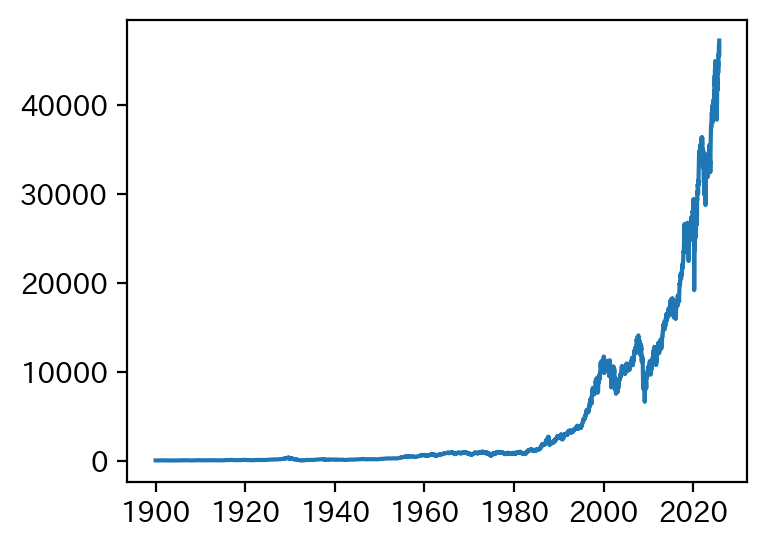

In [31]:
# 終値の可視化
plt.figure(figsize=(4,3))
plt.plot(df_dj['Close'])
plt.show()

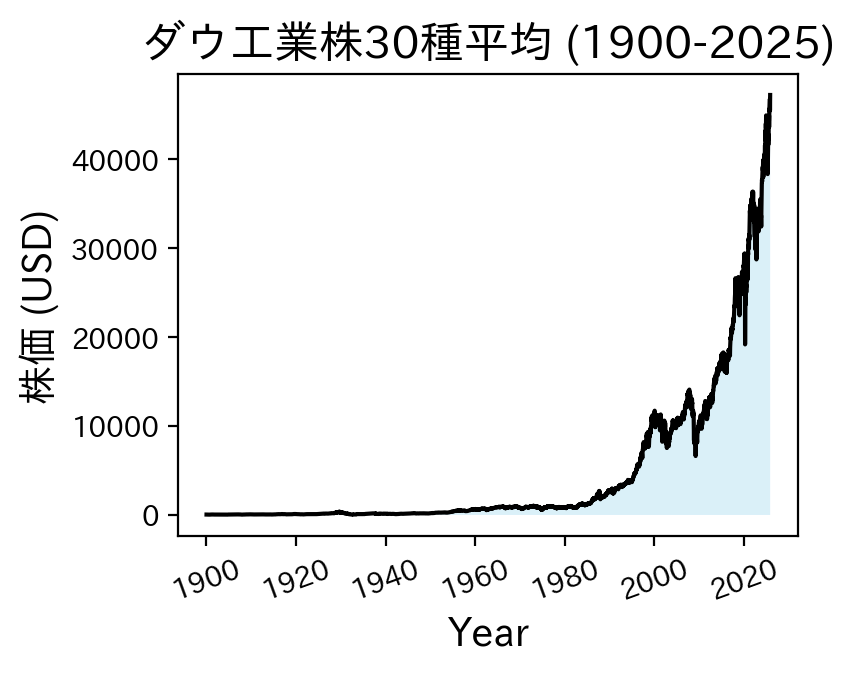

In [32]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# グラフタイトル
plt.title('ダウ工業株30種平均 (1900-2025)', fontsize=16)

# グラフの軸名
plt.xlabel('Year', fontsize=14)
plt.ylabel('株価 (USD)', fontsize=14)

# 折れ線グラフ作成
plt.plot(df_dj['Close'], c="k", lw=1.5)

# グラフの塗りを指定
plt.fill_between(df_dj.index, df_dj['Close'], facecolor='skyblue', alpha=0.3, interpolate=True)

# 軸ラベルの回転
plt.xticks(rotation=20)    # 回転角度指定
plt.show()

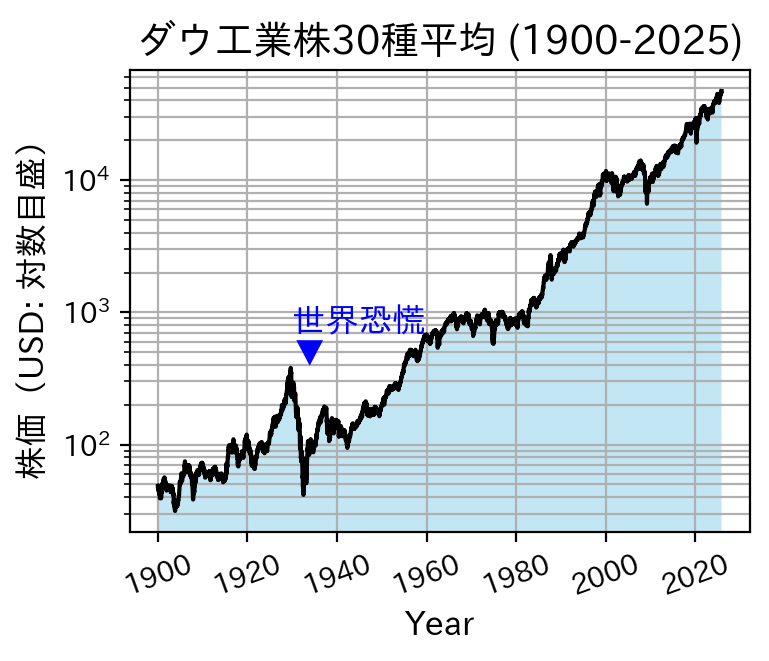

In [33]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# グラフタイトル
plt.title('ダウ工業株30種平均 (1900-2025)', fontsize=14)

# グラフの軸名
plt.xlabel('Year', fontsize=12)
plt.ylabel('株価（USD: 対数目盛）', fontsize=12)
plt.grid(which='both', axis='both')

# 折れ線グラフ作成
plt.plot(df_dj['Close'], c="k", lw=1.5)

# グラフの塗りを指定
plt.fill_between(df_dj.index, df_dj['Close'], facecolor='skyblue', alpha=0.5, interpolate=True)

# 対数目盛
plt.yscale('log') 

# 注釈の追加
plt.annotate("世界恐慌", xy = (datetime.datetime(1930,1,1), 700), size = 12, color = "blue")
plt.annotate("▼", xy = (datetime.datetime(1930,1,1), 400), size = 12, color = "blue");

# 軸ラベルの回転
plt.xticks(rotation=20)    # 回転角度指定
plt.show()

#### datetime型の範囲指定

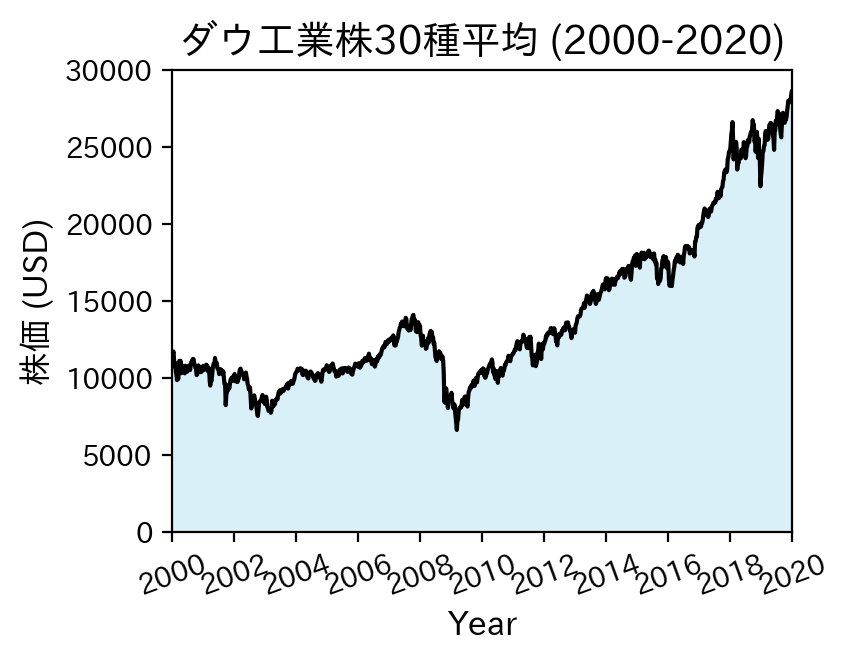

In [34]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# グラフタイトル
plt.title('ダウ工業株30種平均 (2000-2020)', fontsize=14)

# グラフの軸名
plt.xlabel('Year', fontsize=12)
plt.ylabel('株価 (USD)', fontsize=12)

# 折れ線グラフ作成
plt.plot(df_dj['Close'], c="k", lw=1.5)

# グラフの塗りを指定
plt.fill_between(df_dj.index, df_dj['Close'], facecolor='skyblue', alpha=0.3, interpolate=True)

# 軸ラベルの回転
plt.xticks(rotation=20)    # 回転角度指定

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2000, 1, 1), datetime.date(2020, 1, 1))
plt.ylim(0, 30000)
plt.show()

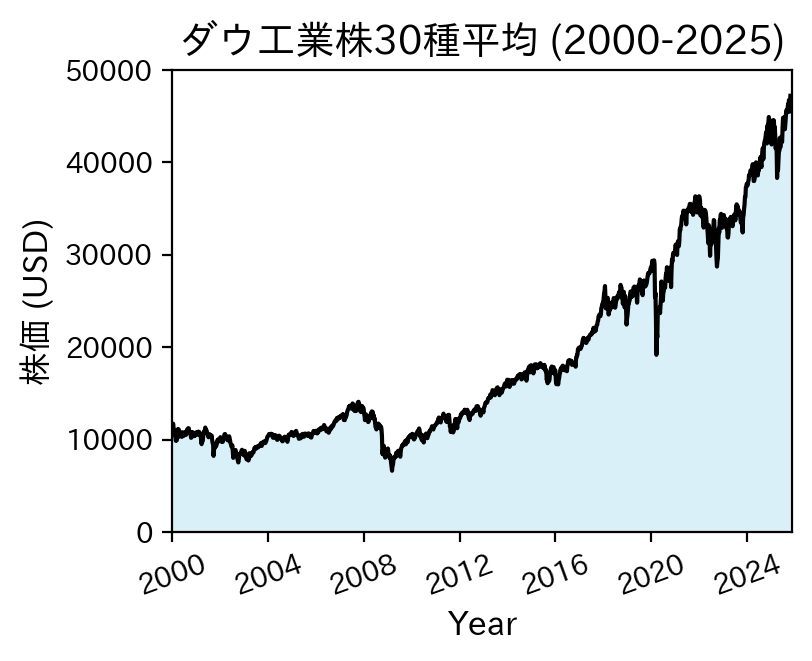

In [35]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# グラフタイトル
plt.title('ダウ工業株30種平均 (2000-2025)', fontsize=14)

# グラフの軸名
plt.xlabel('Year', fontsize=12)
plt.ylabel('株価 (USD)', fontsize=12)

# 折れ線グラフ作成
plt.plot(df_dj['Close'], c="k", lw=1.5)

# グラフの塗りを指定
plt.fill_between(df_dj.index, df_dj['Close'], facecolor='skyblue', alpha=0.3, interpolate=True)

# 軸ラベルの回転
plt.xticks(rotation=20)    # 回転角度指定

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2000, 1, 1), datetime.date.today())
plt.ylim(0, 50000)
plt.show()

### 外国為替相場データ（日次）
https://www.mizuhobank.co.jp/market/historical/index.html

In [36]:
# excelファイルの読み込み
df_exchange = pd.read_excel('exchange.xlsx', skiprows=1, usecols="A:E")
df_exchange

,date,USD,GBP,EUR,CAD
0,2002-04-01,133.15,189.79,116.12,83.48
1,2002-04-02,133.20,191.78,117.18,83.38
2,2002-04-03,133.20,191.26,116.96,83.65
3,2002-04-04,133.10,191.13,117.15,83.72
4,2002-04-05,132.30,189.74,116.32,82.96
...,...,...,...,...,...
5785,2025-11-11,154.36,203.25,178.29,110.04
5786,2025-11-12,154.31,202.86,178.69,110.08
5787,2025-11-13,155.03,203.37,179.51,110.65
5788,2025-11-14,154.74,203.34,179.92,110.21


In [37]:
df_exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5790 entries, 0 to 5789
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    5790 non-null   datetime64[ns]
 1   USD     5790 non-null   float64       
 2   GBP     5790 non-null   float64       
 3   EUR     5790 non-null   float64       
 4   CAD     5790 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 226.3 KB


In [38]:
# date列をインデックスに設定
df_exchange = df_exchange.set_index('date')
df_exchange

,USD,GBP,EUR,CAD
date,,,,
2002-04-01,133.15,189.79,116.12,83.48
2002-04-02,133.20,191.78,117.18,83.38
2002-04-03,133.20,191.26,116.96,83.65
2002-04-04,133.10,191.13,117.15,83.72
2002-04-05,132.30,189.74,116.32,82.96
...,...,...,...,...
2025-11-11,154.36,203.25,178.29,110.04
2025-11-12,154.31,202.86,178.69,110.08
2025-11-13,155.03,203.37,179.51,110.65


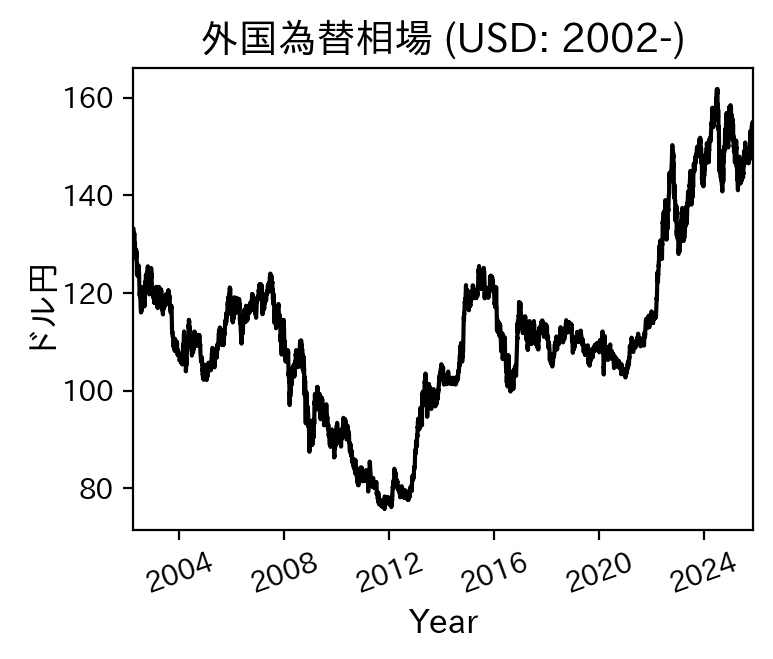

In [39]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# グラフタイトル
plt.title('外国為替相場 (USD: 2002-)', fontsize=14)

# グラフの軸名
plt.xlabel('Year', fontsize=12)
plt.ylabel('ドル円', fontsize=12)

# 折れ線グラフ作成
plt.plot(df_exchange['USD'], c="k", lw=1.5)

# 軸ラベルの回転
plt.xticks(rotation=20)    # 回転角度指定

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2002, 4, 1), datetime.date.today())
#plt.ylim(0, 50000)
plt.show()

### resample による月毎・週毎の集計
参考資料　[resampleをわかりやすく解説！](https://www.yutaka-note.com/entry/pandas_resample)

In [40]:
# 前の月曜日から日曜日までのデータを集計し、日曜日に出力
df_w = df_exchange.resample('W').mean()
df_w

,USD,GBP,EUR,CAD
date,,,,
2002-04-07,132.990000,190.740000,116.7460,83.438000
2002-04-14,131.290000,188.422000,115.4600,82.468000
2002-04-21,131.140000,189.088000,116.0440,82.962000
2002-04-28,129.730000,188.158000,115.6520,82.624000
2002-05-05,128.133333,187.216667,115.7500,81.926667
...,...,...,...,...
2025-10-26,151.664000,202.900000,176.3680,108.260000
2025-11-02,152.820000,202.652000,177.6440,109.410000
2025-11-09,153.800000,201.210000,176.9475,109.090000


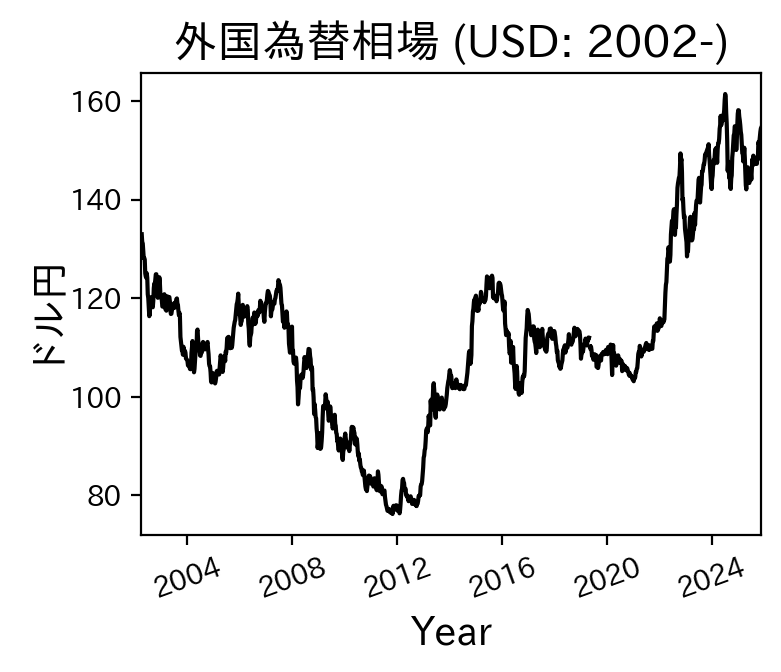

In [41]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# グラフタイトル
plt.title('外国為替相場 (USD: 2002-)', fontsize=16)

# グラフの軸名
plt.xlabel('Year', fontsize=14)
plt.ylabel('ドル円', fontsize=14)

# 折れ線グラフ作成
plt.plot(df_w['USD'], c="k", lw=1.5)

# 軸ラベルの回転
plt.xticks(rotation=20)    # 回転角度指定

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2002, 4, 1), datetime.date.today())
#plt.ylim(0, 50000)
plt.show()

In [42]:
# 月ごとの平均値を集計 (MS: 月始、ME: 末日)
df_m = df_exchange.resample('ME').mean()
df_m

,USD,GBP,EUR,CAD
date,,,,
2002-04-30,131.147619,189.005714,115.973333,82.830476
2002-05-31,126.438095,184.562857,115.884762,81.578571
2002-06-30,123.532500,182.999000,117.825500,80.639500
2002-07-31,118.052174,183.641739,117.226522,76.524783
2002-08-31,119.084091,183.140000,116.451818,75.854545
...,...,...,...,...
2025-07-31,146.740909,198.386364,171.599545,107.293182
2025-08-31,147.713000,198.505000,171.800000,106.988000
2025-09-30,147.989500,199.802000,173.544000,107.037000


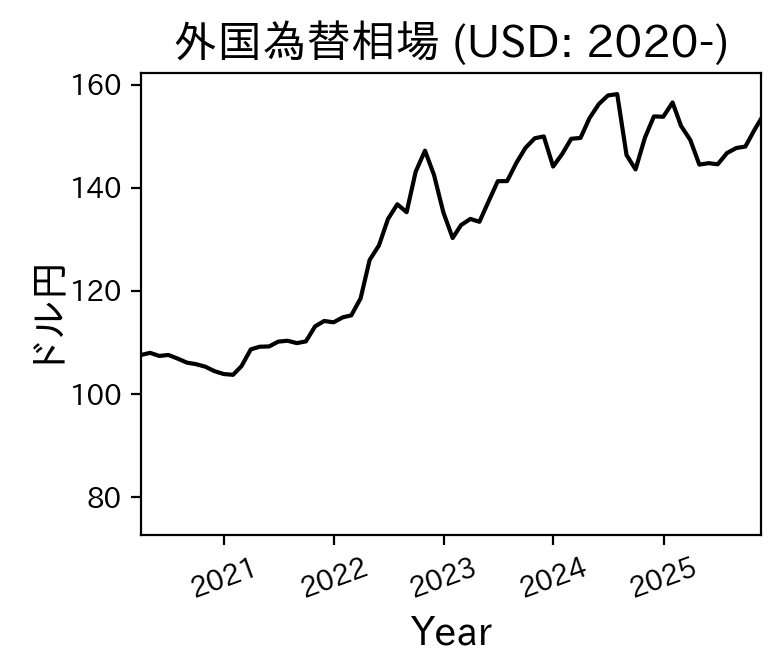

In [43]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# グラフタイトル
plt.title('外国為替相場 (USD: 2020-)', fontsize=16)

# グラフの軸名
plt.xlabel('Year', fontsize=14)
plt.ylabel('ドル円', fontsize=14)

# 折れ線グラフ作成
plt.plot(df_m['USD'], c="k", lw=1.5)

# 軸ラベルの回転
plt.xticks(rotation=20)    # 回転角度指定

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2020, 4, 1), datetime.date.today())
#plt.ylim(0, 50000)
plt.show()

In [44]:
# excelファイルの読み込み
df_ts = pd.read_excel(r"d:\desktop\TimeSeriesResult_20251121212157730.xlsx")
df_ts

,時点,地域コード,地域,総人口（総数）【人】,注記
0,27668,0,全国,111939643,総務省統計局「国勢調査」による。
1,27699,0,全国,112041000,NaN
2,27729,0,全国,112135000,NaN
3,27760,0,全国,112175000,NaN
4,27791,0,全国,112310000,NaN
...,...,...,...,...,...
597,45839,0,全国,123300000,速報
598,45870,0,全国,123300000,速報
599,45901,0,全国,123170000,速報
600,45931,0,全国,123210000,速報


In [45]:
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   時点          602 non-null    int64 
 1   地域コード       602 non-null    int64 
 2   地域          602 non-null    object
 3   総人口（総数）【人】  602 non-null    int64 
 4   注記          15 non-null     object
dtypes: int64(3), object(2)
memory usage: 23.6+ KB


In [46]:
df_ts['日付'] = pd.to_timedelta(df_ts['時点'], unit='D') + pd.to_datetime("1899/12/30")
df_ts

,時点,地域コード,地域,総人口（総数）【人】,注記,日付
0,27668,0,全国,111939643,総務省統計局「国勢調査」による。,1975-10-01
1,27699,0,全国,112041000,NaN,1975-11-01
2,27729,0,全国,112135000,NaN,1975-12-01
3,27760,0,全国,112175000,NaN,1976-01-01
4,27791,0,全国,112310000,NaN,1976-02-01
...,...,...,...,...,...,...
597,45839,0,全国,123300000,速報,2025-07-01
598,45870,0,全国,123300000,速報,2025-08-01
599,45901,0,全国,123170000,速報,2025-09-01
600,45931,0,全国,123210000,速報,2025-10-01


In [47]:
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   時点          602 non-null    int64         
 1   地域コード       602 non-null    int64         
 2   地域          602 non-null    object        
 3   総人口（総数）【人】  602 non-null    int64         
 4   注記          15 non-null     object        
 5   日付          602 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 28.3+ KB


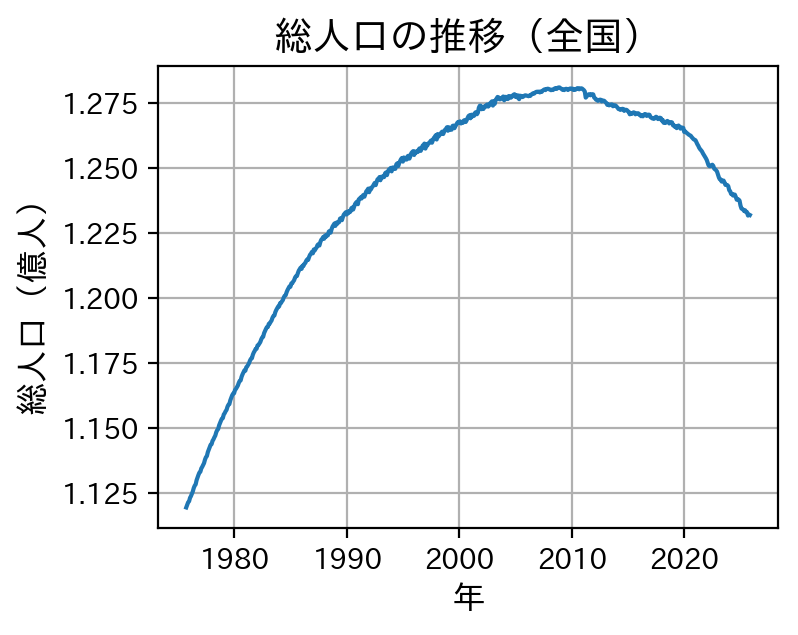

In [48]:
plt.figure(figsize=(4,3))
plt.plot(df_ts['日付'], df_ts['総人口（総数）【人】']/1e8)

# 諸設定
#plt.xlim([23,29])
#plt.ylim([160,188])
plt.title("総人口の推移（全国）", fontsize=14)
plt.xlabel('年', fontsize=12)
plt.ylabel('総人口（億人）', fontsize=12)
plt.grid()
plt.show()

In [49]:
df_ts = df_ts.set_index('日付')
df_ts

,時点,地域コード,地域,総人口（総数）【人】,注記
日付,,,,,
1975-10-01,27668,0,全国,111939643,総務省統計局「国勢調査」による。
1975-11-01,27699,0,全国,112041000,NaN
1975-12-01,27729,0,全国,112135000,NaN
1976-01-01,27760,0,全国,112175000,NaN
1976-02-01,27791,0,全国,112310000,NaN
...,...,...,...,...,...
2025-07-01,45839,0,全国,123300000,速報
2025-08-01,45870,0,全国,123300000,速報
2025-09-01,45901,0,全国,123170000,速報


In [50]:
df_ts

,時点,地域コード,地域,総人口（総数）【人】,注記
日付,,,,,
1975-10-01,27668,0,全国,111939643,総務省統計局「国勢調査」による。
1975-11-01,27699,0,全国,112041000,NaN
1975-12-01,27729,0,全国,112135000,NaN
1976-01-01,27760,0,全国,112175000,NaN
1976-02-01,27791,0,全国,112310000,NaN
...,...,...,...,...,...
2025-07-01,45839,0,全国,123300000,速報
2025-08-01,45870,0,全国,123300000,速報
2025-09-01,45901,0,全国,123170000,速報


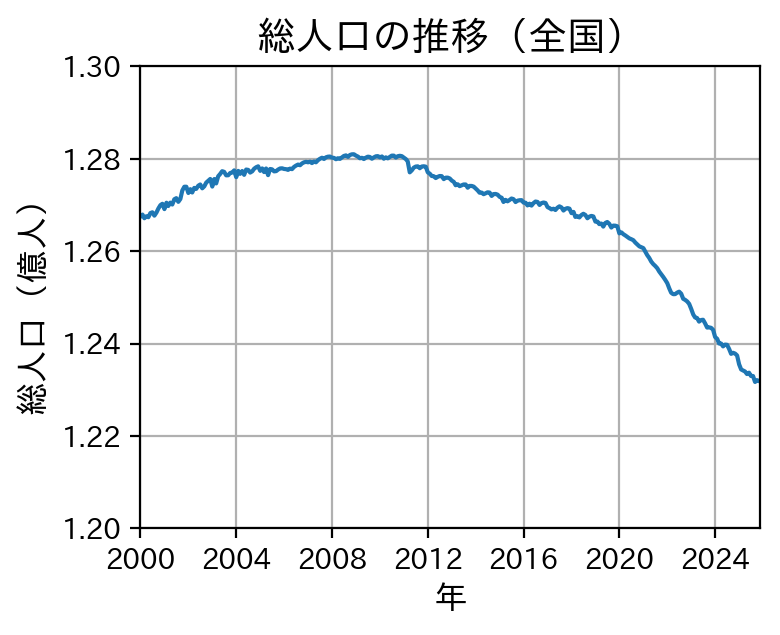

In [51]:
plt.figure(figsize=(4,3))
plt.plot( df_ts['総人口（総数）【人】']/1e8)

# 諸設定
#plt.xlim([23,29])
#plt.ylim([160,188])
plt.title("総人口の推移（全国）", fontsize=14)
plt.xlabel('年', fontsize=12)
plt.ylabel('総人口（億人）', fontsize=12)
plt.grid()

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2000, 1, 1), datetime.date.today())
plt.ylim(1.2, 1.3)
plt.show()

<Axes: xlabel='日付'>

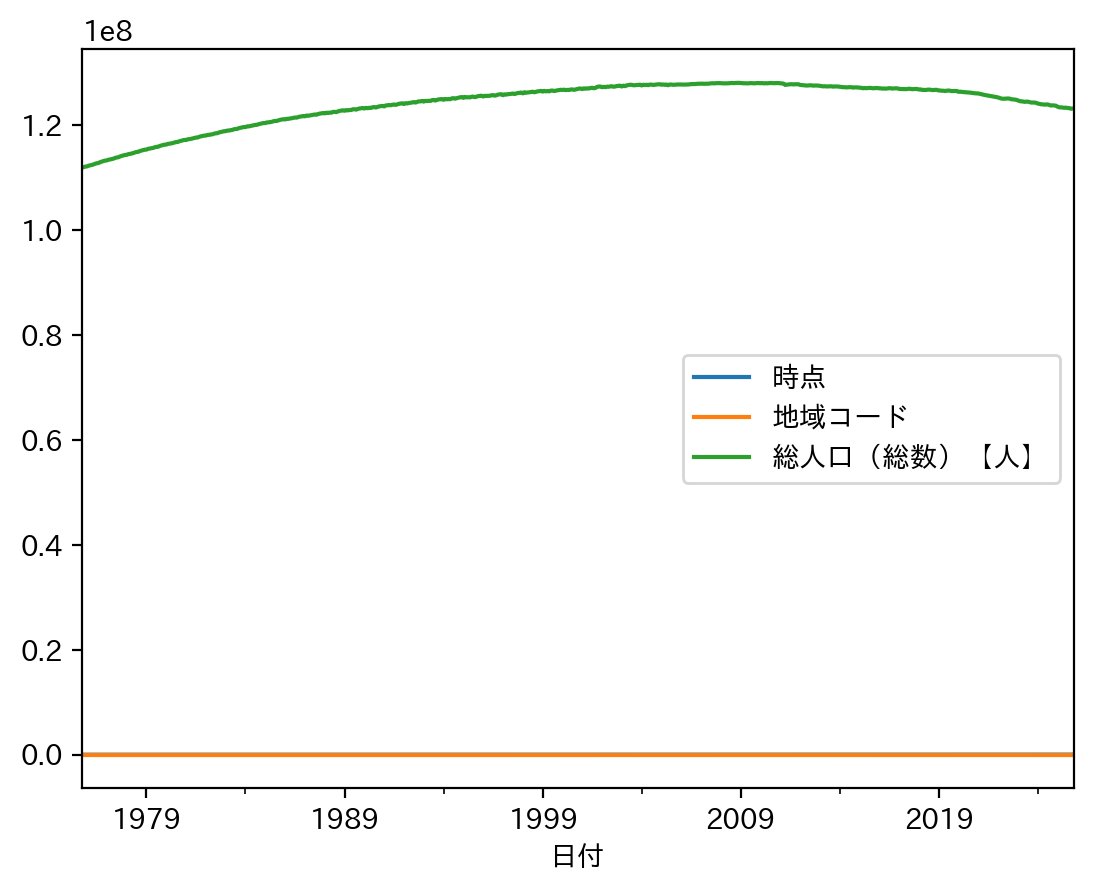

In [52]:
df_ts.plot()

In [53]:
list(range(2000, 2021, 5))

[2000, 2005, 2010, 2015, 2020]

#### 【Matplotlib】時間軸ラベル設定
https://qiita.com/r_beginners/items/bbf16a6012c6252ecc7d  
https://qiita.com/okadate/items/00227316187b60f861f5

#### メモリ設定
https://qiita.com/ground0state/items/c6f0b0923ecb29103e42  
#xloc = mpl.dates.MinuteLocator(byminute=range(0,60,1))  
#xfmt = mpl.dates.DateFormatter("%H:%M")  
#plt.gca().xaxis.set_major_locator(xloc)  
#lt.gca().xaxis.set_major_formatter(xfmt)  

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# サンプルデータ
data = pd.DataFrame({'MAU':np.random.randint(5000, 8500,(30,))},
                     index=pd.date_range('2025/10/1', freq='d', periods=30))
data.head()

,MAU
2025-10-01,5330
2025-10-02,8209
2025-10-03,5284
2025-10-04,7383
2025-10-05,7601


%d: 0埋めした10進数で表記した月中の日にち  
%m: 0埋めした10進数で表記した月  
%y: 0埋めした10進数で表記した西暦の下2桁  
%Y: 0埋めした10進数で表記した西暦4桁  

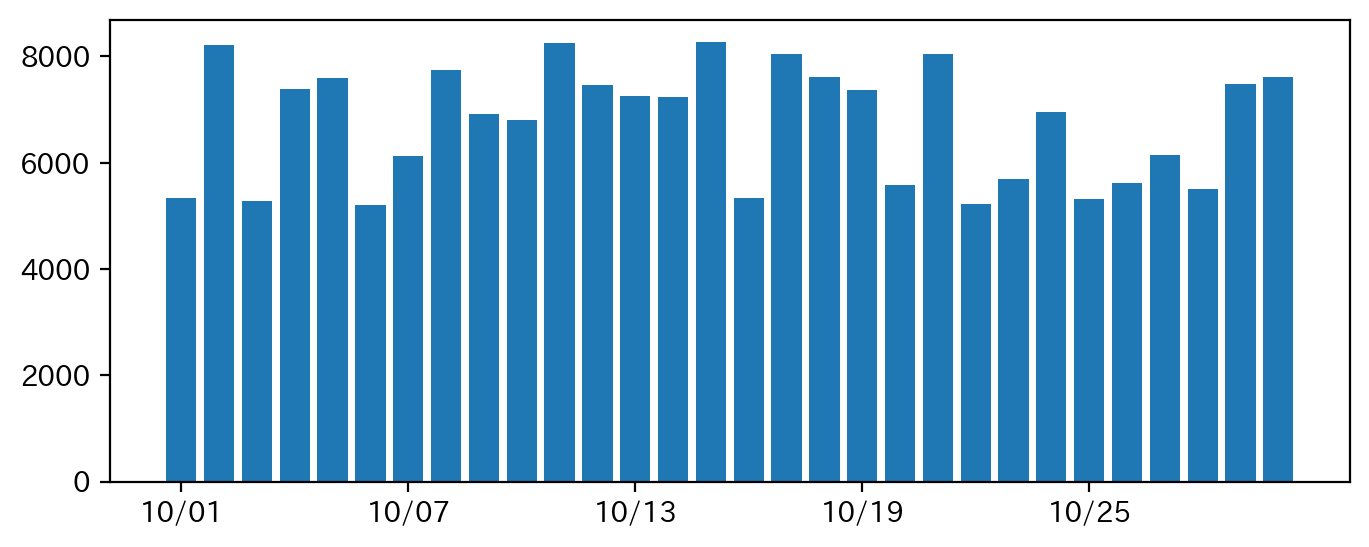

In [55]:
# 数値軸
#from matplotlib import ticker
#ax.xaxis.set_major_locator(ticker.MultipleLocator(20))           # 20ごと
#ax.xaxis.set_major_locator(ticker.MaxNLocator(5))                # 最大5個

# 時間軸
#from matplotlib import dates as mdates
#ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))   # 最大8個
#ax.xaxis.set_major_locator(mdates.HourLocator(12))               # 12時
#ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))      # 24時間ごと
#x.xaxis.set_major_locator(mdates.DayLocator(np.arange(1,31,7)))  # 1週間ごと

# positions = [0,1,2,3,4,5,6,7,8,9]
# labels = ['Dec\n2019','26','27','28','29','30','31','Jan\n2020','2','3']
# ax.xaxis.set_major_locator(ticker.FixedLocator(positions))
# ax.xaxis.set_major_formatter(ticker.FixedFormatter(labels))

# グラフサイズ指定
plt.figure(figsize=(8,3))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=4))   # 最大8個
plt.gca().xaxis.set_major_locator(mdates.DayLocator(np.arange(1,31,6))) # 1週間ごと
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.bar(data.index, data['MAU'])
plt.show()